## 1. 데이터 확보

주식 상위 30개 코인 상위 10개 데이터 다운로드 및 정제

In [14]:
import yfinance as yf
import pandas as pd

sp500_tickers = [
    'NVDA',   # 엔비디아
    'AAPL',   # 애플
    'MSFT',   # 마이크로소프트
    'AMZN',   # 아마존
    'GOOGL',  # 알파벳 A
    'META',   # 메타 플랫폼스
    'BRK-B',  # 버크셔 해서웨이
    'LLY',    # 일라이 릴리
    'AVGO',   # 브로드컴
    'TSLA',   # 테슬라
    'WMT',    # 월마트
    'JPM',    # JP모건 체이스
    'UNH',    # 유나이티드헬스 그룹
    'XOM',    # 엑슨모빌
    'V',      # 비자
    'MA',     # 마스터카드
    'JNJ',    # 존슨앤드존슨
    'PG',     # 프록터 앤 갬블
    'ORCL',   # 오라클
    'HD',     # 홈디포
    'COST',   # 코스트코
    'ABBV',   # 애비비
    'BAC',    # 뱅크오브아메리카
    'NFLX',   # 넷플릭스
    'CVX',    # 쉐브론
    'AMD',    # AMD
    'KO',     # 코카콜라
    'CAT',    # 캐터필러
    'PLTR',   # 팔란티어
    'MU'      # 마이크론 테크놀로지
]

crypto_tickers = [
    'BTC-USD',   # 1. 비트코인 
    'ETH-USD',   # 2. 이더리움 
    'USDT-USD',  # 3. 테더 
    'BNB-USD',   # 4. 바이낸스 코인
    'XRP-USD',   # 5. 리플 
    'USDC-USD',  # 6. 유에스디 코인
    'SOL-USD',   # 7. 솔라나 
    'TRX-USD',   # 8. 트론
    'DOGE-USD',  # 9. 도지코인 
    'ADA-USD'    # 10. 카르다노
]

tickers = sp500_tickers + crypto_tickers

stock_data = yf.download(sp500_tickers, period='5y', interval='1d', auto_adjust=True)
crypto_data = yf.download(crypto_tickers, period='5y', interval='1d', auto_adjust=True)
data = pd.concat([stock_data, crypto_data], axis = 1)

[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  10 of 10 completed
C:\Users\skack\AppData\Local\Temp\ipykernel_37908\1332215659.py:54: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  data = pd.concat([stock_data, crypto_data], axis = 1)


In [15]:
stock_data.to_csv("RAW stock data.csv")
crypto_data.to_csv("RAW crypto data.csv")
data.to_csv("RAW data.csv")

In [16]:
print("="*10,"data 형태 (행, 열):","="*10)
print(data.shape)
print("="*10,"columns","="*10)
print(data.columns[0:5])
print("="*10,"head","="*10)
print(data.head())


========== data 형태 (행, 열): ==========
(1827, 200)
========== columns ==========
MultiIndex([('Close', 'AAPL'),
            ('Close', 'ABBV'),
            ('Close',  'AMD'),
            ('Close', 'AMZN'),
            ('Close', 'AVGO')],
           names=['Price', 'Ticker'])
========== head ==========
Price            Close                                               \
Ticker            AAPL       ABBV        AMD        AMZN       AVGO   
Date                                                                  
2021-04-08  126.970062  87.623634  83.349998  164.964996  43.923393   
2021-04-09  129.541382  88.812881  82.760002  168.610001  43.888115   
2021-04-10         NaN        NaN        NaN         NaN        NaN   
2021-04-11         NaN        NaN        NaN         NaN        NaN   
2021-04-12  127.827187  89.399239  78.580002  168.969498  43.759632   

Price                                                                 ...  \
Ticker            BAC       BRK-B         CAT        

In [17]:
stock_close = stock_data['Close']
crypto_close = crypto_data['Close']
data_close = data['Close']

In [18]:
print("="*10,"data_close 형태 (행, 열)","="*10)
print(data_close.shape)
print("="*10,"columns","="*10)
print(data_close.columns[0:5])
print("="*10,"head","="*10)
print(data_close.head())
print("="*10,"결측 0나와야함","="*10)
print("주식:",stock_close.isnull().sum().max())
print("코인:",crypto_close.isnull().sum().max())
print("전체:",data_close.isnull().sum().max())

========== data_close 형태 (행, 열) ==========
(1827, 40)
========== columns ==========
Index(['AAPL', 'ABBV', 'AMD', 'AMZN', 'AVGO'], dtype='str', name='Ticker')
========== head ==========
Ticker            AAPL       ABBV        AMD        AMZN       AVGO  \
Date                                                                  
2021-04-08  126.970062  87.623634  83.349998  164.964996  43.923393   
2021-04-09  129.541382  88.812881  82.760002  168.610001  43.888115   
2021-04-10         NaN        NaN        NaN         NaN        NaN   
2021-04-11         NaN        NaN        NaN         NaN        NaN   
2021-04-12  127.827187  89.399239  78.580002  168.969498  43.759632   

Ticker            BAC       BRK-B         CAT        COST        CVX  ...  \
Date                                                                  ...   
2021-04-08  35.159538  263.510010  210.199936  341.985046  83.656387  ...   
2021-04-09  35.416378  266.010010  210.446213  343.869049  83.575203  ...   
2021-04-

In [19]:
stock_close.to_csv("Close stock data.csv")
crypto_close.to_csv("Close crypto data.csv")
data_close.to_csv("Close data.csv")

In [20]:
data_close_filled = data_close.ffill()

In [21]:
data_close_filled.to_csv("Close&Filled data.csv")

In [22]:
print("="*10,"data_close 형태 (행, 열)","="*10)
print(data_close_filled.shape)
print("="*10,"columns","="*10)
print(data_close_filled.columns)
print("="*10,"head","="*10)
print(data_close_filled.head())
print("="*10,"결측","="*10)
print("주식:",stock_close.isnull().sum().max())
print("코인:",crypto_close.isnull().sum().max())
print("전체:",data_close_filled.isnull().sum().max())

========== data_close 형태 (행, 열) ==========
(1827, 40)
========== columns ==========
Index(['AAPL', 'ABBV', 'AMD', 'AMZN', 'AVGO', 'BAC', 'BRK-B', 'CAT', 'COST',
       'CVX', 'GOOGL', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 'META', 'MSFT',
       'MU', 'NFLX', 'NVDA', 'ORCL', 'PG', 'PLTR', 'TSLA', 'UNH', 'V', 'WMT',
       'XOM', 'ADA-USD', 'BNB-USD', 'BTC-USD', 'DOGE-USD', 'ETH-USD',
       'SOL-USD', 'TRX-USD', 'USDC-USD', 'USDT-USD', 'XRP-USD'],
      dtype='str', name='Ticker')
========== head ==========
Ticker            AAPL       ABBV        AMD        AMZN       AVGO  \
Date                                                                  
2021-04-08  126.970062  87.623634  83.349998  164.964996  43.923393   
2021-04-09  129.541382  88.812881  82.760002  168.610001  43.888115   
2021-04-10  129.541382  88.812881  82.760002  168.610001  43.888115   
2021-04-11  129.541382  88.812881  82.760002  168.610001  43.888115   
2021-04-12  127.827187  89.399239  78.580002  168.969498  43.

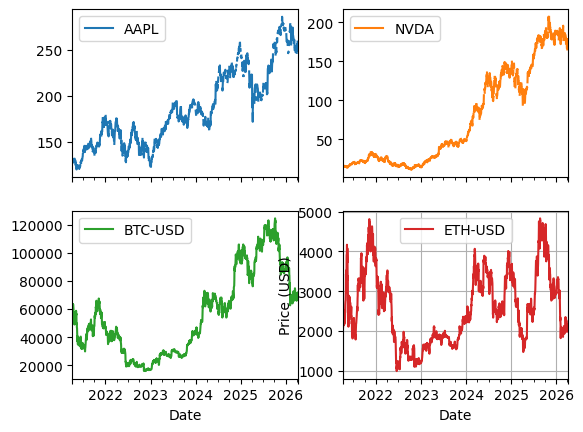

In [23]:
import matplotlib.pyplot as plt

data_close[['AAPL','NVDA','BTC-USD','ETH-USD']].plot.line(subplots=True, layout = (2,2))
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

In [24]:
returns = data_close_filled.pct_change()
stock_returns = stock_close.pct_change()
crypto_returns = crypto_close.pct_change()
returns.isnull().sum()

Ticker
AAPL        1
ABBV        1
AMD         1
AMZN        1
AVGO        1
BAC         1
BRK-B       1
CAT         1
COST        1
CVX         1
GOOGL       1
HD          1
JNJ         1
JPM         1
KO          1
LLY         1
MA          1
META        1
MSFT        1
MU          1
NFLX        1
NVDA        1
ORCL        1
PG          1
PLTR        1
TSLA        1
UNH         1
V           1
WMT         1
XOM         1
ADA-USD     1
BNB-USD     1
BTC-USD     1
DOGE-USD    1
ETH-USD     1
SOL-USD     1
TRX-USD     1
USDC-USD    1
USDT-USD    1
XRP-USD     1
dtype: int64

In [27]:
returns = returns.dropna()
stock_returns = stock_returns.dropna()
crypto_returns = crypto_returns.dropna()

print("="*10,"returns 형태 (행, 열)","="*10)
print(returns.shape)
print("="*10,"stock_returns 형태 (행, 열)","="*10)
print(stock_returns.shape)
print("="*10,"crypto_returns 형태 (행, 열)","="*10)
print(crypto_returns.shape)
print(returns.head())
print('='*30)
print(returns.tail())
print('='*30)
print(stock_returns.head())
print('='*30)
print(stock_returns.tail())
print('='*30)
print(crypto_returns.head())
print('='*30)
print(crypto_returns.tail())

========== returns 형태 (행, 열) ==========
(1826, 40)
========== stock_returns 형태 (행, 열) ==========
(1254, 30)
========== crypto_returns 형태 (행, 열) ==========
(1826, 10)
Ticker          AAPL      ABBV       AMD      AMZN      AVGO       BAC  \
Date                                                                     
2021-04-09  0.020251  0.013572 -0.007079  0.022096 -0.000803  0.007305   
2021-04-10  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2021-04-11  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2021-04-12 -0.013233  0.006602 -0.050507  0.002132 -0.002928  0.001750   
2021-04-13  0.024306 -0.000277  0.020489  0.006099  0.002667 -0.018472   

Ticker         BRK-B       CAT      COST       CVX  ...   ADA-USD   BNB-USD  \
Date                                                ...                       
2021-04-09  0.009487  0.001172  0.005509 -0.000970  ... -0.013036  0.084059   
2021-04-10  0.000000  0.000000  0.000000  0.000000  ...  0.012644  0.042769   

In [26]:
stock_returns.to_csv("stock returns.csv")
crypto_returns.to_csv("crypto returns.csv")
returns.to_csv("returns.csv")